In [ ]:
!pip install datasets

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_wine, make_blobs, make_moons, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF, PCA, LatentDirichletAllocation
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from gensim.models import LdaModel, CoherenceModel
from gensim import corpora
import gensim

from collections import Counter

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Clusterização - Dataset Wine Quality

In [ ]:
wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)

wine_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [ ]:
wine_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [ ]:
wine_df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [ ]:
wine_df = wine_df.rename(columns={'od280/od315_of_diluted_wines': 'diluted'})

In [ ]:
# StandardScaler
scaler = StandardScaler()
wine_scaled = scaler.fit_transform(wine_df)

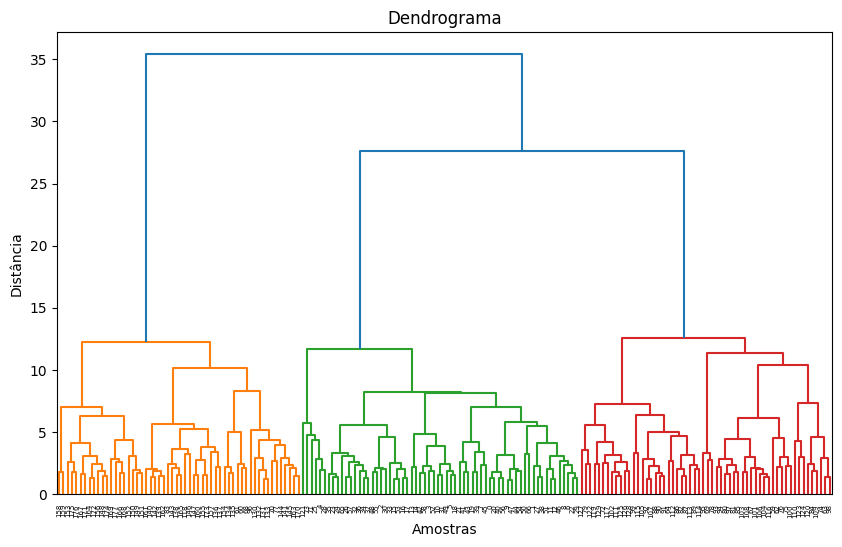

In [ ]:
# Clusterização aglomerativa hierárquica
Z = linkage(wine_scaled, method='ward')

# Plotando o dendrograma
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Dendrograma')
plt.xlabel('Amostras')
plt.ylabel('Distância')
plt.show()

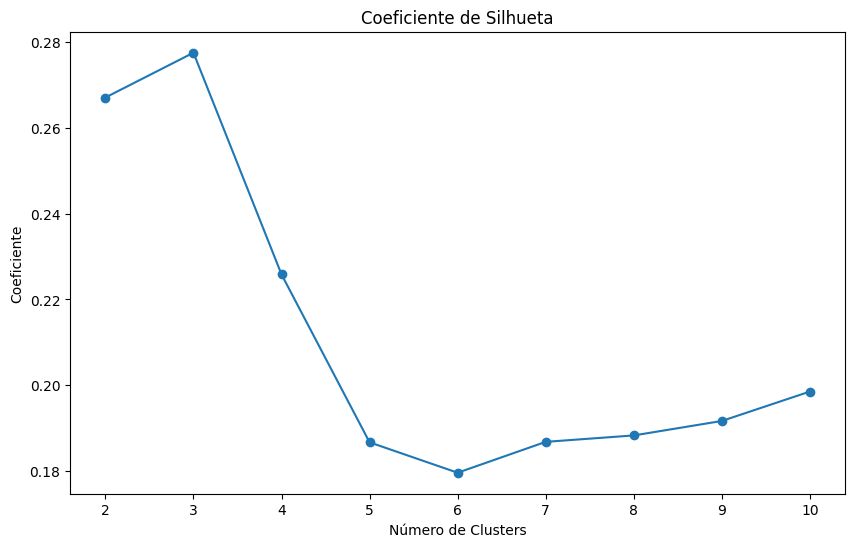

In [ ]:
# Coeficiente de silhueta
range_n_clusters = list(range(2, 11))
silhouette_avg = []

for n_clusters in range_n_clusters:
    clustering = AgglomerativeClustering(n_clusters=n_clusters, affinity='euclidean', linkage='ward')
    cluster_labels = clustering.fit_predict(wine_scaled)
    silhouette_avg.append(silhouette_score(wine_scaled, cluster_labels))

# Plotando o coeficiente
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_avg, marker='o')
plt.title('Coeficiente de Silhueta')
plt.xlabel('Número de Clusters')
plt.ylabel('Coeficiente')
plt.show()

Resultados:

* O dendrograma sugere que entre 3 e 5 clusters são apropriados.
* O coeficiente de silhueta é mais alto para 3 clusters, indicando que este é o número de clusters que melhor equilibra a coesão interna e a separação entre clusters.

Possíveis melhorias:

* Explorar diferentes métodos de linkage, testando métodos como complete, average e single linkage, que podem produzir diferentes estruturas de cluster.
* Remover outliers: a remoção de outliers pode reduzir a variabilidade dentro dos clusters e melhorar os coeficientes de silhueta.
* Adicionar mais características: se tivermos mais dados ou características, podemos enriquecer a análise, o que pode resultar em clusters mais bem definidos.
* Validar com outros índices: utilizar outros índices de validação, como o índice de Davies-Bouldin, para corroborar os resultados e garantir a robustez da análise.
* Experimentar com outros algoritmos de clusterização: algoritmos como K-means ou DBSCAN podem oferecer insights adicionais ou revelar uma estrutura de cluster diferente.

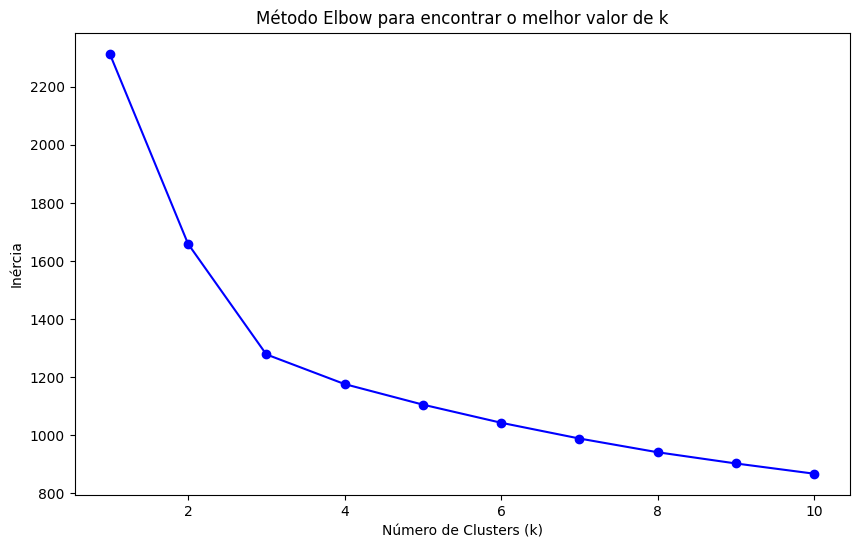

In [ ]:
# Método Elbow
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(wine_scaled)
    inertia.append(kmeans.inertia_)

# Plotando o gráfico do método Elbow
plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bo-')
plt.title('Método Elbow para encontrar o melhor valor de k')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.show()

In [ ]:
# Melhor valor de k
best_k = 3

# Ajustando o modelo KMeans com o melhor valor de k
kmeans = KMeans(n_clusters=best_k, random_state=42)
cluster_labels = kmeans.fit_predict(wine_scaled)

# Calculando o coeficiente de silhueta
silhouette_avg_kmeans = silhouette_score(wine_scaled, cluster_labels)
print(f'Coeficiente de Silhueta para KMeans com k={best_k}: {silhouette_avg_kmeans}')

Coeficiente de Silhueta para KMeans com k=3: 0.2848589191898987


In [ ]:
# Melhor número de clusters para clusterização aglomerativa hierárquica
best_num_clusters_agg = 3

# Coeficiente de silhueta para clusterização aglomerativa hierárquica com melhor número de clusters
silhouette_avg_best = silhouette_avg[best_num_clusters_agg - 2]
print(f'Coeficiente de Silhueta para Clusterização Aglomerativa com {best_num_clusters_agg} clusters: {silhouette_avg_best}')

# Comparação dos resultados
print(f'\nComparação dos Coeficientes de Silhueta:')
print(f'KMeans: {silhouette_avg_kmeans}')
print(f'Clusterização Aglomerativa Hierárquica: {silhouette_avg_best}')

Coeficiente de Silhueta para Clusterização Aglomerativa com 3 clusters: 0.2774439826952265

Comparação dos Coeficientes de Silhueta:
KMeans: 0.2848589191898987
Clusterização Aglomerativa Hierárquica: 0.2774439826952265


# DBSCAN

DBSCAN é um algoritmo de clusterização que identifica grupos (clusters) de dados com base na densidade de pontos. Ele é útil para encontrar clusters de forma arbitrária e detectar pontos de ruído.

* Epsilon: distância máxima para considerar que dois pontos estão na mesma vizinhança.
* MinPts: número mínimo de pontos necessários para formar um cluster denso.


---


* Pontos core: pontos com pelo menos MinPts em sua vizinhança. Eles formam o núcleo dos clusters.
* Pontos de borda: pontos que estão na vizinhança de um ponto core, mas têm menos que MinPts em sua própria vizinhança.
* Ruído: pontos que não são pontos core nem pontos de borda. Eles não pertencem a nenhum cluster.


---

Código explicando o passo a passo da implementação do DBSCAN:

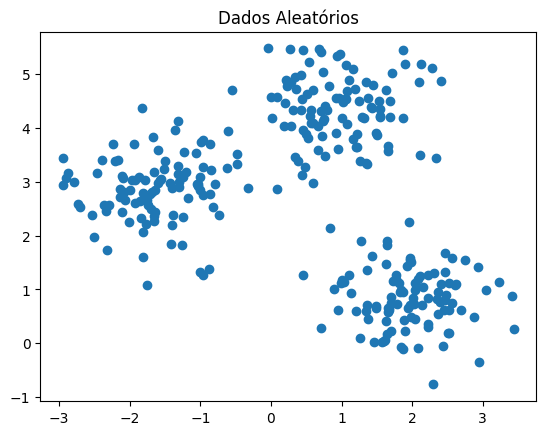

In [ ]:
# Dados aleatórios com 3 clusters
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

# Visualizando os dados gerados
plt.scatter(X[:, 0], X[:, 1])
plt.title('Dados Aleatórios')
plt.show()

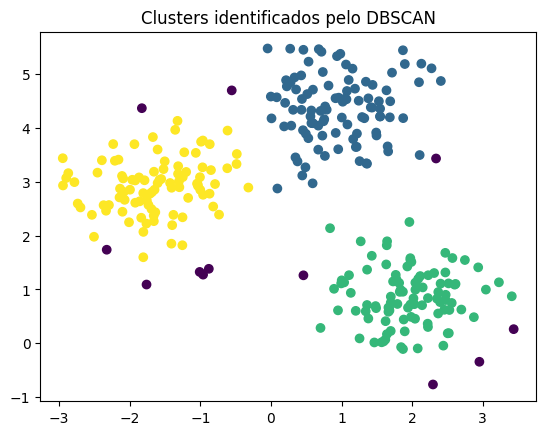

In [ ]:
# Parâmetros do DBSCAN
epsilon = 0.5
min_samples = 5

# Aplicando o DBSCAN
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
dbscan.fit(X)

# Obtendo os rótulos dos clusters
labels_db = dbscan.labels_

# Visualizando os clusters
plt.scatter(X[:, 0], X[:, 1], c=labels_db, cmap='viridis')
plt.title('Clusters identificados pelo DBSCAN')
plt.show()

1. Escolha um ponto não visitado:

  O DBSCAN começa escolhendo um ponto não visitado aleatoriamente. Este processo é interno ao algoritmo e não é explicitamente visível no código.

2. Verifique a vizinhança:

  O algoritmo verifica quantos pontos estão dentro da distância epsilon (eps).

In [ ]:
# Vizinhos dentro da distância epsilon
neighbors = NearestNeighbors(radius=epsilon)
neighbors.fit(X)
distances, indices = neighbors.radius_neighbors([X[0]])

print('Vizinhança do primeiro ponto:', indices[0])

Vizinhança do primeiro ponto: [ 96 146   7 141 110 163   0  23  31  68  84 158  38  56]


3. Classificação do Ponto:

* Ponto Core: Se a vizinhança tem pelo menos min_samples, o ponto é um ponto core.
* Ponto de Borda: Se a vizinhança tem menos que min_samples, mas está dentro da vizinhança de um ponto core.
* Ruído: Se o ponto não for um ponto core e não estiver na vizinhança de um ponto core.

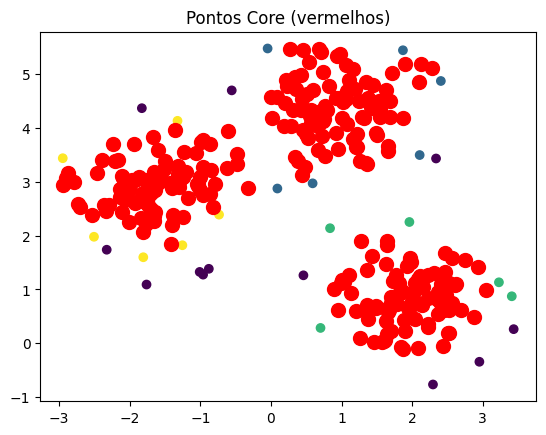

In [ ]:
core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

# Visualizando pontos core
plt.scatter(X[:, 0], X[:, 1], c=labels_db, cmap='viridis')
plt.scatter(X[core_samples_mask, 0], X[core_samples_mask, 1], c='red', marker='o', s=100)
plt.title('Pontos Core (vermelhos)')
plt.show()

4. Formação de Cluster:

  O DBSCAN forma clusters expandindo a partir dos pontos core.

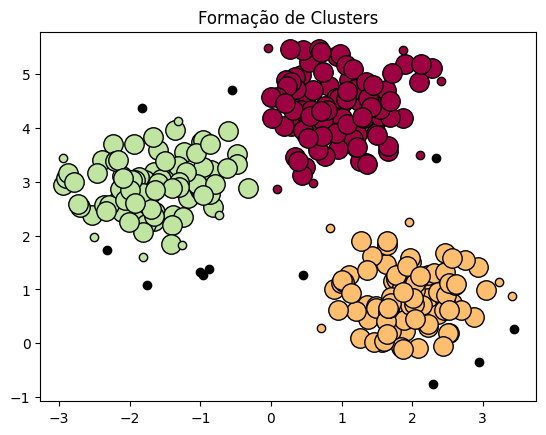

In [ ]:
unique_labels = set(labels_db)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Cor preta para ruído

    class_member_mask = (labels_db == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=14)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

plt.title('Formação de Clusters')
plt.show()

5. Marcação de ponto visitado:

  Por fim, o DBSCAN marca os pontos como visitados internamente, atualizando os rótulos dos pontos.

# DBSCAN para clusterização no dataset sintético make_moons

In [ ]:
# Gerando o dataset sintético make_moons
X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

# Normalizando os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicando o algoritmo DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
cluster_labels = dbscan.fit_predict(X_scaled)

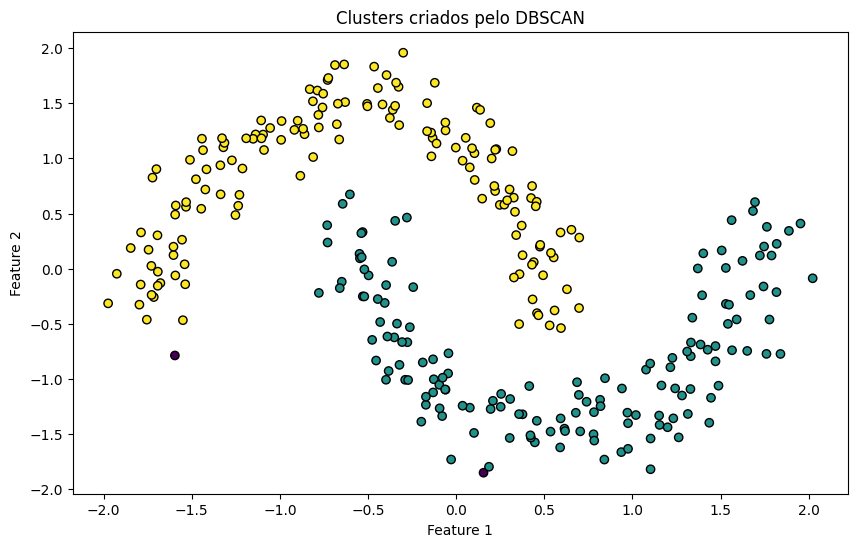

In [ ]:
# Plotando os clusters criados
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=cluster_labels, cmap='viridis', marker='o', edgecolor='k')
plt.title('Clusters criados pelo DBSCAN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Dataset Amazon Massive Intent

In [ ]:
amazon_df = pd.read_json('hf://datasets/SetFit/amazon_massive_intent_en-US/train.jsonl', lines=True)
amazon_df

,id,label,text,label_text
0,1,48,wake me up at nine am on friday,alarm_set
1,2,48,set an alarm for two hours from now,alarm_set
2,4,46,olly quiet,audio_volume_mute
3,5,46,stop,audio_volume_mute
4,6,46,olly pause for ten seconds,audio_volume_mute
...,...,...,...,...
11509,17175,17,send hi in watsapp to vikki,email_querycontact
11510,17176,44,do i have emails,email_query
11511,17177,44,what emails are new,email_query
11512,17178,44,do i have new emails from john,email_query


In [ ]:
# Limpeza dos dados removendo caracteres especiais, números e pontuações
def clean_tokenize(text):
  text = re.sub(r'\d+', '', text)
  text = re.sub(r'\W', ' ', text)
  text = text.lower()
  tokens = word_tokenize(text)
  tokens = [word for word in tokens if len(word) >=3]
  return tokens

amazon_df['Tokenized_text'] = amazon_df['text'].apply(clean_tokenize)
amazon_df

,id,label,text,label_text,Tokenized_text
0,1,48,wake me up at nine am on friday,alarm_set,"[wake, nine, friday]"
1,2,48,set an alarm for two hours from now,alarm_set,"[set, alarm, for, two, hours, from, now]"
2,4,46,olly quiet,audio_volume_mute,"[olly, quiet]"
3,5,46,stop,audio_volume_mute,[stop]
4,6,46,olly pause for ten seconds,audio_volume_mute,"[olly, pause, for, ten, seconds]"
...,...,...,...,...,...
11509,17175,17,send hi in watsapp to vikki,email_querycontact,"[send, watsapp, vikki]"
11510,17176,44,do i have emails,email_query,"[have, emails]"
11511,17177,44,what emails are new,email_query,"[what, emails, are, new]"
11512,17178,44,do i have new emails from john,email_query,"[have, new, emails, from, john]"


In [ ]:
# Removendo as stopwords
stop_words = set(stopwords.words('english'))

amazon_df['Text_stopwords'] = amazon_df['Tokenized_text'].apply(lambda x: [word for word in x if word not in stop_words])

In [ ]:
# Lematização
lemmatizer = WordNetLemmatizer()

amazon_df['Lemmatized_text'] = amazon_df['Text_stopwords'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

In [ ]:
def comparar_colunas(row):
    if row['Lemmatized_text'] == row['Text_stopwords']:
        return 'Igual'
    else:
        return 'Diferente'

amazon_df['comparacao'] = amazon_df.apply(comparar_colunas, axis=1)
amazon_df

,id,label,text,label_text,Tokenized_text,Text_stopwords,Lemmatized_text,comparacao
0,1,48,wake me up at nine am on friday,alarm_set,"[wake, nine, friday]","[wake, nine, friday]","[wake, nine, friday]",Igual
1,2,48,set an alarm for two hours from now,alarm_set,"[set, alarm, for, two, hours, from, now]","[set, alarm, two, hours]","[set, alarm, two, hour]",Diferente
2,4,46,olly quiet,audio_volume_mute,"[olly, quiet]","[olly, quiet]","[olly, quiet]",Igual
3,5,46,stop,audio_volume_mute,[stop],[stop],[stop],Igual
4,6,46,olly pause for ten seconds,audio_volume_mute,"[olly, pause, for, ten, seconds]","[olly, pause, ten, seconds]","[olly, pause, ten, second]",Diferente
...,...,...,...,...,...,...,...,...
11509,17175,17,send hi in watsapp to vikki,email_querycontact,"[send, watsapp, vikki]","[send, watsapp, vikki]","[send, watsapp, vikki]",Igual
11510,17176,44,do i have emails,email_query,"[have, emails]",[emails],[email],Diferente
11511,17177,44,what emails are new,email_query,"[what, emails, are, new]","[emails, new]","[email, new]",Diferente
11512,17178,44,do i have new emails from john,email_query,"[have, new, emails, from, john]","[new, emails, john]","[new, email, john]",Diferente


In [ ]:
# Cálculo do TF-IDF

amazon_df['Final_text'] = amazon_df['Lemmatized_text'].apply(lambda x: ' '.join(x))

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(amazon_df['Final_text'])

print(tfidf_matrix.shape)
print(tfidf_matrix)

(11514, 4509)
  (0, 1569)	0.5439342475450012
  (0, 2715)	0.5489174269307553
  (0, 4344)	0.6346851130752732
  (1, 1871)	0.5761520496771159
  (1, 4235)	0.518005474335565
  (1, 81)	0.45135724747147876
  (1, 3603)	0.4427141056779361
  (2, 3187)	0.8680404900395183
  (2, 2795)	0.49649341148896736
  (3, 3880)	1.0
  (4, 3565)	0.5421260057345435
  (4, 4050)	0.43385169485344394
  (4, 2905)	0.6329501846542
  (4, 2795)	0.34241227274342556
  (5, 3565)	0.577006139572394
  (5, 4050)	0.4617655101329055
  (5, 2905)	0.6736739037156336
  (6, 4360)	0.5241132847581674
  (6, 406)	0.5440079456489004
  (6, 2274)	0.5566163974532589
  (6, 2384)	0.3457438443371376
  (7, 3248)	0.5154027026114503
  (7, 3933)	0.6017787841520617
  (7, 3014)	0.21462646527492535
  (7, 2274)	0.501499258924348
  :	:
  (11505, 1289)	0.29866439386314947
  (11505, 3558)	0.5114307847464482
  (11505, 2528)	0.5605526225551701
  (11506, 4466)	0.8023795573479645
  (11506, 1289)	0.44332783517500873
  (11506, 3014)	0.39955910264831257
  (11507, 3

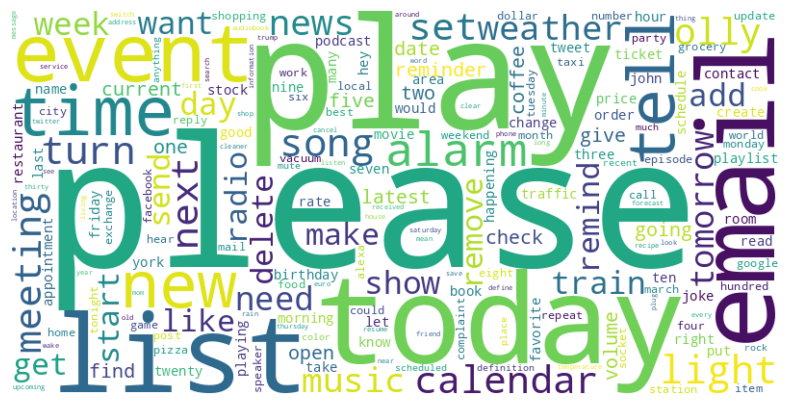

In [ ]:
# Nuvem de palavras com WordCloud

# Calculando o valor médio de TF-IDF para cada palavra
tfidf_means = np.mean(tfidf_matrix.toarray(), axis=0)

# Obtendo os nomes das palavras (features)
feature_names = vectorizer.get_feature_names_out()

# Criando um dicionário de palavras e seus valores de TF-IDF
tfidf_dict = {feature_names[i]: tfidf_means[i] for i in range(len(feature_names))}

# Gerando a nuvem de palavras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tfidf_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
amazon_df.columns

Index(['id', 'label', 'text', 'label_text', 'Tokenized_text', 'Text_stopwords',
       'Lemmatized_text', 'comparacao', 'Final_text'],
      dtype='object')

In [ ]:
# Eliminando as variáveis utilizadas no pré-processamento para não poluir tanto o dataset
del amazon_df['Tokenized_text']
del amazon_df['Text_stopwords']
del amazon_df['Lemmatized_text']
del amazon_df['comparacao']
amazon_df

,id,label,text,label_text,Final_text
0,1,48,wake me up at nine am on friday,alarm_set,wake nine friday
1,2,48,set an alarm for two hours from now,alarm_set,set alarm two hour
2,4,46,olly quiet,audio_volume_mute,olly quiet
3,5,46,stop,audio_volume_mute,stop
4,6,46,olly pause for ten seconds,audio_volume_mute,olly pause ten second
...,...,...,...,...,...
11509,17175,17,send hi in watsapp to vikki,email_querycontact,send watsapp vikki
11510,17176,44,do i have emails,email_query,email
11511,17177,44,what emails are new,email_query,email new
11512,17178,44,do i have new emails from john,email_query,new email john


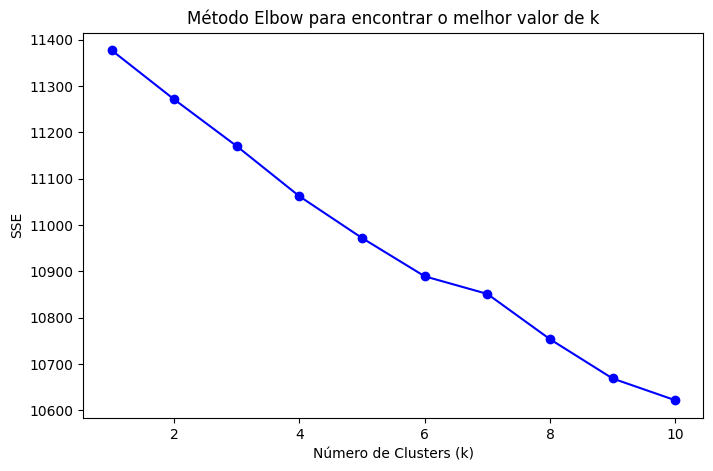

In [ ]:
# Método Elbow
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tfidf_matrix)
    inertia.append(kmeans.inertia_)

# Plotando o gráfico do método Elbow
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.title('Método Elbow para encontrar o melhor valor de k')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('SSE')
plt.show()

O método Elbow calculou 9 como sendo o nº ótimo de clusters, no ponto onde a queda é menos acentuada e onde a adição de mais tópicos não fornece uma melhoria significativa na métrica.

# Algoritmo NMF

In [ ]:
# Definindo o nº de tópicos
num_topics = 9

# Aplicando NMF
nmf_model = NMF(n_components=num_topics, random_state=42)
nmf_model.fit(tfidf_matrix)

# Obtendo os tópicos
nmf_topics = nmf_model.components_

In [ ]:
# Identificando as palavras mais representativas de cada tópico
terms = vectorizer.get_feature_names_out()
top_n = 10

for topic_idx, topic in enumerate(nmf_topics):
    print(f'Tópico {topic_idx}:')
    sorted_indices = topic.argsort()[-top_n:][::-1]
    top_terms = [terms[i] for i in sorted_indices]
    print('Palavras mais representativas:', top_terms)
    print()

Tópico 0:
Palavras mais representativas: ['event', 'calendar', 'next', 'delete', 'remove', 'add', 'week', 'upcoming', 'clear', 'scheduled']

Tópico 1:
Palavras mais representativas: ['email', 'new', 'send', 'check', 'contact', 'reply', 'york', 'add', 'address', 'last']

Tópico 2:
Palavras mais representativas: ['turn', 'light', 'room', 'change', 'living', 'kitchen', 'socket', 'volume', 'radio', 'color']

Tópico 3:
Palavras mais representativas: ['alarm', 'set', 'tomorrow', 'meeting', 'reminder', 'morning', 'five', 'eight', 'seven', 'six']

Tópico 4:
Palavras mais representativas: ['play', 'song', 'music', 'playlist', 'favorite', 'radio', 'podcast', 'next', 'want', 'game']

Tópico 5:
Palavras mais representativas: ['list', 'remove', 'shopping', 'item', 'grocery', 'delete', 'add', 'new', 'create', 'tell']

Tópico 6:
Palavras mais representativas: ['today', 'weather', 'date', 'news', 'meeting', 'day', 'need', 'olly', 'like', 'going']

Tópico 7:
Palavras mais representativas: ['time', 'tra

In [ ]:
amazon_df.columns

Index(['id', 'label', 'text', 'label_text', 'Final_text'], dtype='object')

In [ ]:
labels = amazon_df['label']
label_names = amazon_df['label_text']

H = nmf_model.transform(tfidf_matrix)
topics = H.argmax(axis=1)

topic_label = {i: labels[(topics == i)] for i in range(H.shape[1])}

for topic, index_list in topic_label.items():
  counter = Counter(topic_label[topic])
  print("=========================")
  print(f'Tópico {topic}: {len(index_list)} amostras')

  sample_count = 0
  for label_index, count in sorted(counter.items(), key=lambda x: x[1],
                                   reverse=True):
    print(f'{label_names[label_index]}: {count} amostras')
    sample_count += 1
    if sample_count >= 5:
        break

Tópico 0: 776 amostras
music_likeness: 223 amostras
general_quirky: 205 amostras
datetime_query: 150 amostras
iot_hue_lightchange: 95 amostras
iot_hue_lightoff: 20 amostras
Tópico 1: 1312 amostras
music_likeness: 369 amostras
datetime_convert: 313 amostras
iot_cleaning: 80 amostras
music_query: 73 amostras
play_music: 65 amostras
Tópico 2: 715 amostras
alarm_remove: 139 amostras
alarm_set: 107 amostras
iot_cleaning: 65 amostras
general_greet: 62 amostras
takeaway_query: 51 amostras
Tópico 3: 997 amostras
music_likeness: 292 amostras
music_query: 165 amostras
datetime_query: 112 amostras
play_music: 108 amostras
music_likeness: 63 amostras
Tópico 4: 1743 amostras
music_likeness: 553 amostras
takeaway_query: 187 amostras
takeaway_order: 149 amostras
takeaway_order: 131 amostras
iot_cleaning: 104 amostras
Tópico 5: 766 amostras
takeaway_order: 180 amostras
calendar_query: 160 amostras
iot_hue_lightup: 151 amostras
iot_cleaning: 37 amostras
music_query: 30 amostras
Tópico 6: 1790 amostras


Análise dos resultados:

* Cada tópico identificado pelo NMF representa um conjunto de palavras frequentemente associadas em diferentes documentos.
* As palavras mais representativas de cada tópico ajudam a entender a temática dos clusters formados.
* A análise dessas palavras permite associar cada tópico a um tema específico, a exemplo da agregação das palavras que remetem a configurações de alarme e lanterna (Tópico 6), ou à música (Tópico 1) e etc.
* Diferentemente do KMeans, que agrupa documentos, o NMF identifica temas latentes nos dados.

# Algoritmo LDA

In [ ]:
# Criação e ajuste do modelo LDA do sklearn
lda_model = LatentDirichletAllocation(n_components=10, random_state=0)
lda_model.fit(tfidf_matrix)

# Transformando a matriz tfidf com o modelo LDA
H = lda_model.transform(tfidf_matrix)

# Identificando o tópico principal de cada documento
topics = H.argmax(axis=1)

# Criando o dicionário topic_label
topic_label = {i: labels[(topics == i)] for i in range(H.shape[1])}

# Limitando a impressão a apenas 5 amostras por tópico
for topic, index_list in topic_label.items():
    counter = Counter(topic_label[topic])
    print("=========================")
    print(f'Tópico {topic}: {len(index_list)} amostras')

    sample_count = 0
    for label_index, count in sorted(counter.items(), key=lambda x: x[1], reverse=True):
        print(f'{label_names.iloc[label_index]}: {count} amostras')
        sample_count += 1
        if sample_count >= 5:
            break

Tópico 0: 1180 amostras
music_likeness: 273 amostras
audio_volume_mute: 82 amostras
takeaway_order: 65 amostras
takeaway_query: 65 amostras
iot_hue_lightdim: 58 amostras
Tópico 1: 798 amostras
takeaway_order: 99 amostras
iot_hue_lightchange: 92 amostras
music_likeness: 71 amostras
music_query: 44 amostras
iot_hue_lightoff: 40 amostras
Tópico 2: 1084 amostras
takeaway_query: 115 amostras
alarm_remove: 111 amostras
iot_hue_lightchange: 62 amostras
iot_cleaning: 59 amostras
iot_hue_lightchange: 48 amostras
Tópico 3: 1399 amostras
music_likeness: 327 amostras
datetime_convert: 188 amostras
iot_hue_lightoff: 130 amostras
play_music: 69 amostras
play_music: 66 amostras
Tópico 4: 1018 amostras
play_music: 203 amostras
iot_hue_lightchange: 106 amostras
iot_hue_lightoff: 74 amostras
news_query: 65 amostras
alarm_set: 55 amostras
Tópico 5: 1181 amostras
iot_hue_lightup: 114 amostras
takeaway_order: 111 amostras
calendar_query: 103 amostras
iot_hue_lightchange: 94 amostras
general_quirky: 82 amos

In [ ]:
amazon_df.columns

Index(['id', 'label', 'text', 'label_text', 'Final_text'], dtype='object')

In [ ]:
# Preparação dos textos para calcular a coerência
texts = [doc.split() for doc in amazon_df['Final_text']]

# Criação do dicionário e corpus para o gensim
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

In [ ]:
# Tópicos do NMF
nmf_topics = [[feature_names[i] for i in topic.argsort()[:-11:-1]] for topic in nmf_model.components_]

# Coerência do NMF
coherence_model_nmf = CoherenceModel(topics=nmf_topics, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_nmf = coherence_model_nmf.get_coherence()
print(f'Coerência dos Tópicos do NMF: {coherence_nmf:.2f}')

Coerência dos Tópicos do NMF: 0.42


In [ ]:
# Tópicos do LDA
lda_topics = [[feature_names[i] for i in topic.argsort()[:-11:-1]] for topic in lda_model.components_]

# Coerência do LDA
coherence_model_lda = CoherenceModel(topics=lda_topics, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print(f'Coerência dos Tópicos do LDA: {coherence_lda:.2f}')

Coerência dos Tópicos do LDA: 0.33


Análise dos resultados:

O dataset foi classificado em 9 tópicos principais, com alguma sobreposição de palavras nos tópicos. O modelo NMF obteve uma performance melhor de coerência dos tópicos (0.42), sendo sua implementação preferível em relação ao LDA (0.33).

Particularmente, fiquei com a impressão que os resultados poderiam ser melhores, haja vista o dataset já possuir rótulos de classificação de cada texto. Talvez incrementar mais alguns passos do pré-processamento possa melhorar a performance dos modelos.

# Dataset Breast Cancer - Algoritmo KMeans com método PCA

In [ ]:
# Carregando o dataset e separando features e target
data = load_breast_cancer()
X = data.data
y = data.target

df_cancer = pd.DataFrame(X, columns=data.feature_names)
df_cancer

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

# Distância dos pontos para os centroides
distances = kmeans.transform(X)

pd.DataFrame(distances)

,0,1,2,3
0,1221.247406,1044.817288,427.204952,1656.381506
1,1289.987895,913.784035,393.883004,1740.899791
2,1016.573938,1186.112050,121.120902,1467.688531
3,395.387748,2584.715817,1286.962045,86.626530
4,967.197260,1271.953609,179.258299,1415.676271
...,...,...,...,...
564,1438.685731,781.842517,547.323717,1889.355521
565,1067.487674,1141.028270,178.741961,1518.660566
566,336.910100,1866.447055,563.044221,787.984303
567,1145.691609,1058.416723,249.915081,1596.937881


In [ ]:
# PCA
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)

pd.DataFrame(X_pca)

,0,1,2,3
0,1160.142574,-293.917544,48.578398,-8.711975
1,1269.122443,15.630182,-35.394534,17.861283
2,995.793889,39.156743,-1.709753,4.199340
3,-407.180803,-67.380320,8.672848,-11.759867
4,930.341180,189.340742,1.374801,8.499183
...,...,...,...,...
564,1414.126684,110.222492,40.065944,6.562240
565,1045.018854,77.057589,0.036669,-4.753245
566,314.501756,47.553525,-10.442407,-9.771881
567,1124.858115,34.129225,-19.742087,-23.660881


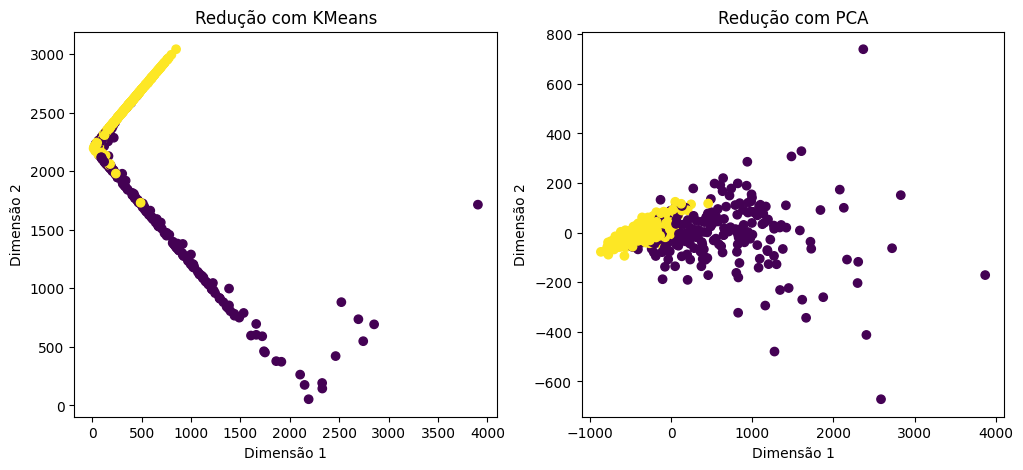

In [ ]:
# Comparando os resultados
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(distances[:, 0], distances[:, 1], c=y, cmap='viridis')
plt.title('Redução com KMeans')
plt.xlabel('Dimensão 1')
plt.ylabel('Dimensão 2')

# Plotar as primeiras duas dimensões das características reduzidas por PCA
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title('Redução com PCA')
plt.xlabel('Dimensão 1')
plt.ylabel('Dimensão 2')

plt.show()